# Feature Engineering

En este notebook se crearán nuevas variables a partir del dataset limpio obtenido en la etapa anterior.

El objetivo del feature engineering es transformar variables existentes en características más informativas para el análisis y el modelado supervisado. Estas nuevas variables permitirán representar mejor factores asociados al riesgo cardiovascular, como el índice de masa corporal, categorías de presión arterial, obesidad, riesgo metabólico y hábitos de vida.

En esta etapa se trabajará con el archivo `cardio_clean.csv`, generado después del proceso de limpieza. No se entrenarán modelos todavía; el propósito es preparar un dataset enriquecido para la siguiente fase del proyecto.

Las principales transformaciones que se realizarán son:

- Creación del índice de masa corporal (`bmi`).
- Clasificación del IMC en categorías.
- Creación de un indicador de obesidad.
- Clasificación de la presión arterial.
- Creación de un indicador de hipertensión.
- Creación de variables relacionadas con riesgo metabólico.
- Creación de variables relacionadas con hábitos de riesgo.
- Construcción de un puntaje general de riesgo cardiovascular.
- Revisión final de correlaciones con la variable objetivo `cardio`.

In [1]:
# Librerías principales
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid")

In [2]:
# Cargar dataset limpio generado en la etapa anterior
df = pd.read_csv("cardio_clean.csv")

# Vista inicial
df.head()

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.00,110,80,1,1,0,0,1,0
1,55,1,156,85.00,140,90,3,1,0,0,1,1
2,51,1,165,64.00,130,70,3,1,0,0,0,1
3,48,2,169,82.00,150,100,1,1,0,0,1,1
4,47,1,156,56.00,100,60,1,1,0,0,0,0


In [3]:
# Dimensiones del dataset limpio
df.shape

(68636, 12)

In [4]:
# Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68636 entries, 0 to 68635
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age_years    68636 non-null  int64  
 1   gender       68636 non-null  int64  
 2   height       68636 non-null  int64  
 3   weight       68636 non-null  float64
 4   ap_hi        68636 non-null  int64  
 5   ap_lo        68636 non-null  int64  
 6   cholesterol  68636 non-null  int64  
 7   gluc         68636 non-null  int64  
 8   smoke        68636 non-null  int64  
 9   alco         68636 non-null  int64  
 10  active       68636 non-null  int64  
 11  cardio       68636 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.3 MB


In [5]:
# Primeras filas
df.head()

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.00,110,80,1,1,0,0,1,0
1,55,1,156,85.00,140,90,3,1,0,0,1,1
2,51,1,165,64.00,130,70,3,1,0,0,0,1
3,48,2,169,82.00,150,100,1,1,0,0,1,1
4,47,1,156,56.00,100,60,1,1,0,0,0,0


## Creación del IMC

Se creó la variable `bmi`, correspondiente al Índice de Masa Corporal. Esta variable relaciona el peso y la altura de cada persona, por lo que puede aportar más información que analizar ambas variables por separado.

El IMC será utilizado posteriormente para crear categorías de peso y un indicador de obesidad.

In [6]:
# Crear Índice de Masa Corporal (IMC)
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

# Revisar primeros registros
df[["height", "weight", "bmi"]].head()

,height,weight,bmi
0,168,62.00,21.97
1,156,85.00,34.93
2,165,64.00,23.51
3,169,82.00,28.71
4,156,56.00,23.01


In [7]:
# Estadísticas descriptivas del IMC
df["bmi"].describe()

count   68636.00
mean       27.46
std         5.26
min        10.73
25%        23.88
50%        26.35
75%        30.12
max        74.38
Name: bmi, dtype: float64

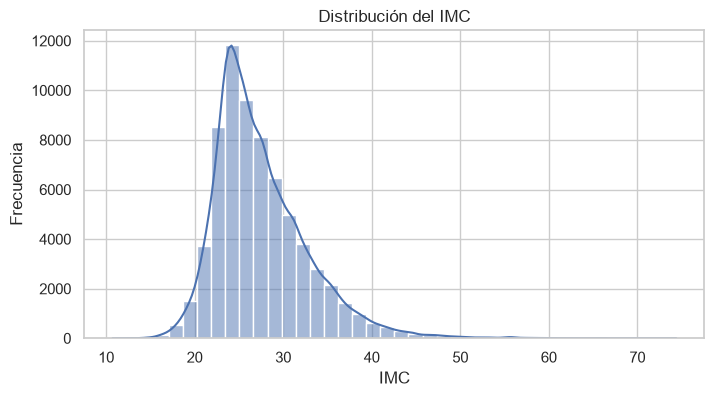

In [8]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x="bmi", bins=40, kde=True)

plt.title("Distribución del IMC")
plt.xlabel("IMC")
plt.ylabel("Frecuencia")

plt.show()

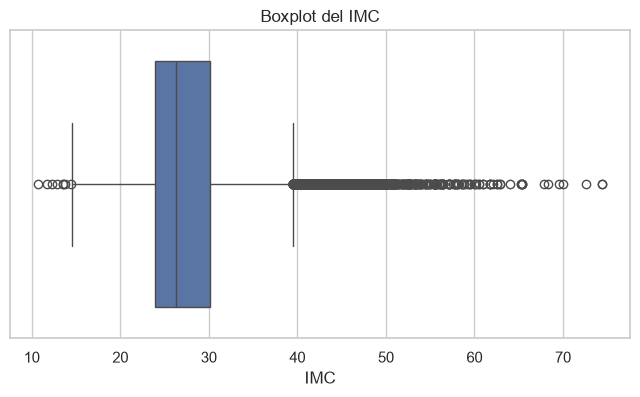

In [9]:
plt.figure(figsize=(8, 4))

sns.boxplot(data=df, x="bmi")

plt.title("Boxplot del IMC")
plt.xlabel("IMC")

plt.show()

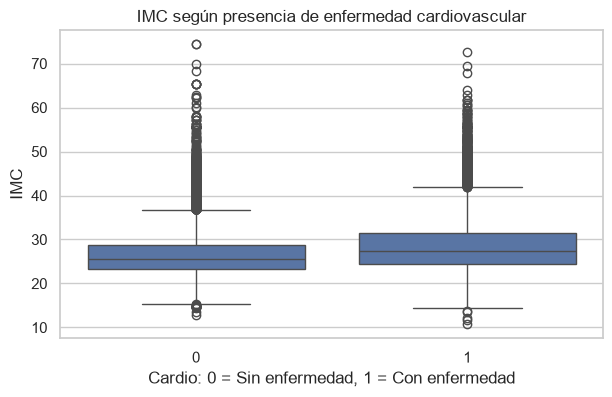

In [10]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df, x="cardio", y="bmi")

plt.title("IMC según presencia de enfermedad cardiovascular")
plt.xlabel("Cardio: 0 = Sin enfermedad, 1 = Con enfermedad")
plt.ylabel("IMC")

plt.show()

In [11]:
# Media y mediana de IMC según cardio
df.groupby("cardio")["bmi"].agg(["mean", "median", "std"])

,mean,median,std
cardio,,,
0,26.48,25.47,4.84
1,28.47,27.43,5.48


## Categorizar IMC

In [12]:


# Crear categorías de IMC según rangos estándar para adultos
def clasificar_bmi(bmi):
    if bmi < 18.5:
        return "bajo_peso"
    elif bmi < 25:
        return "normal"
    elif bmi < 30:
        return "sobrepeso"
    else:
        return "obesidad"

df["bmi_category"] = df["bmi"].apply(clasificar_bmi)

# Revisar distribución de la nueva variable
df["bmi_category"].value_counts()

bmi_category
normal       25425
sobrepeso    24626
obesidad     17947
bajo_peso      638
Name: count, dtype: int64

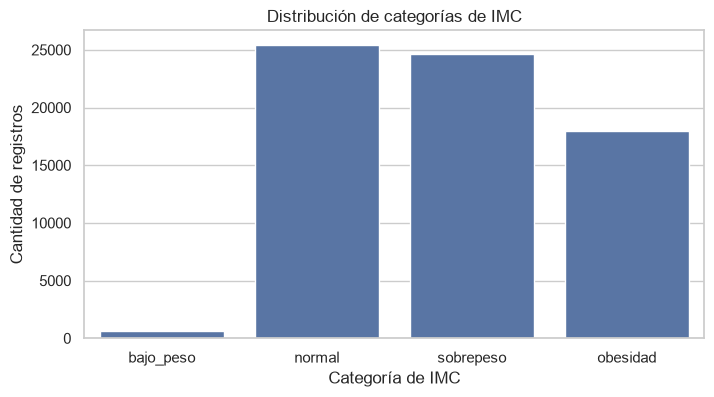

In [13]:
plt.figure(figsize=(8, 4))

sns.countplot(
    data=df,
    x="bmi_category",
    order=["bajo_peso", "normal", "sobrepeso", "obesidad"]
)

plt.title("Distribución de categorías de IMC")
plt.xlabel("Categoría de IMC")
plt.ylabel("Cantidad de registros")

plt.show()

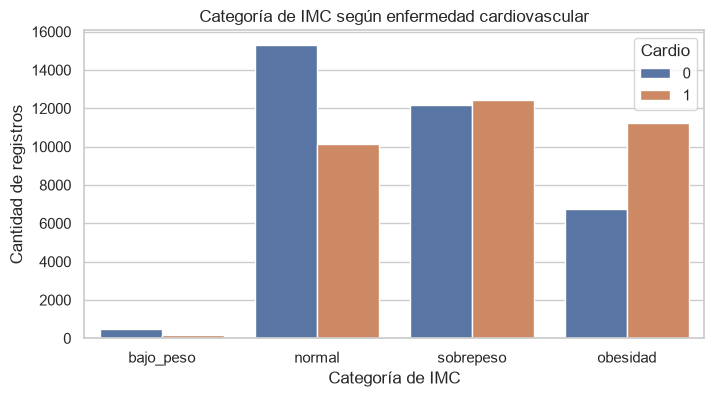

In [14]:
plt.figure(figsize=(8, 4))

sns.countplot(
    data=df,
    x="bmi_category",
    hue="cardio",
    order=["bajo_peso", "normal", "sobrepeso", "obesidad"]
)

plt.title("Categoría de IMC según enfermedad cardiovascular")
plt.xlabel("Categoría de IMC")
plt.ylabel("Cantidad de registros")
plt.legend(title="Cardio")

plt.show()

In [ ]:
# Calcular porcentaje de pacientes con enfermedad cardiovascular en cada categoría de IMC
bmi_cardio_pct = (
    df.groupby("bmi_category")["cardio"]
    .mean()
    .reset_index()
)

bmi_cardio_pct["Porcentaje_cardio_1"] = bmi_cardio_pct["cardio"] * 100

bmi_cardio_pct = bmi_cardio_pct.set_index("bmi_category").loc[
    ["bajo_peso", "normal", "sobrepeso", "obesidad"]
].reset_index()

bmi_cardio_pct

,bmi_category,cardio,Porcentaje_cardio_1
0,bajo_peso,0.27,27.27
1,normal,0.40,39.79
2,sobrepeso,0.51,50.55
3,obesidad,0.62,62.49


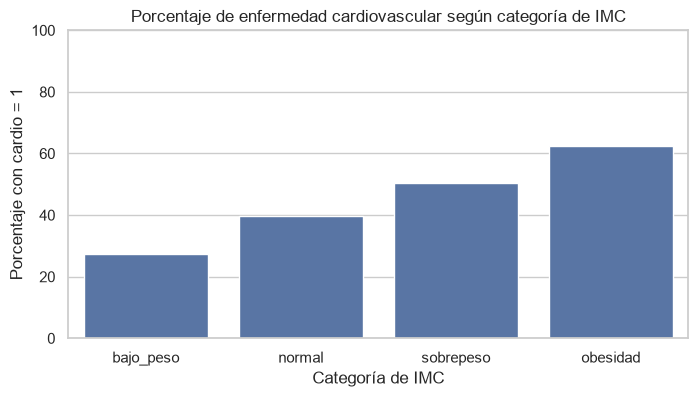

In [16]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=bmi_cardio_pct,
    x="bmi_category",
    y="Porcentaje_cardio_1",
    order=["bajo_peso", "normal", "sobrepeso", "obesidad"]
)

plt.title("Porcentaje de enfermedad cardiovascular según categoría de IMC")
plt.xlabel("Categoría de IMC")
plt.ylabel("Porcentaje con cardio = 1")
plt.ylim(0, 100)

plt.show()

## Creacion de indicador de obesidad

In [17]:
# Crear variable binaria de obesidad
df["obesity"] = (df["bmi"] >= 30).astype(int)

# Revisar distribución
df["obesity"].value_counts()

obesity
0    50689
1    17947
Name: count, dtype: int64

In [18]:
# Porcentaje de obesidad
df["obesity"].value_counts(normalize=True).sort_index() * 100

obesity
0   73.85
1   26.15
Name: proportion, dtype: float64

In [ ]:
# relacion entre obesidad y enfermedad cardiovascular
obesity_cardio_pct = (
    df.groupby("obesity")["cardio"]
    .mean()
    .reset_index()
)

obesity_cardio_pct["Porcentaje_cardio_1"] = obesity_cardio_pct["cardio"] * 100

obesity_cardio_pct

,obesity,cardio,Porcentaje_cardio_1
0,0,0.45,44.86
1,1,0.62,62.49


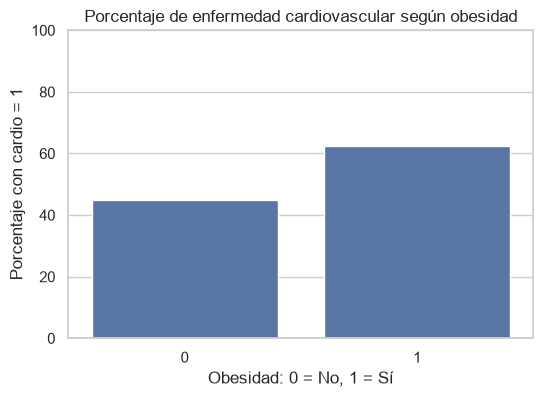

In [20]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=obesity_cardio_pct,
    x="obesity",
    y="Porcentaje_cardio_1"
)

plt.title("Porcentaje de enfermedad cardiovascular según obesidad")
plt.xlabel("Obesidad: 0 = No, 1 = Sí")
plt.ylabel("Porcentaje con cardio = 1")
plt.ylim(0, 100)

plt.show()

## Creacion de categorias de presion arterial

In [21]:
# Crear categorías de presión arterial
def clasificar_presion(row):
    ap_hi = row["ap_hi"]
    ap_lo = row["ap_lo"]
    
    if ap_hi < 120 and ap_lo < 80:
        return "normal"
    elif 120 <= ap_hi < 130 and ap_lo < 80:
        return "elevada"
    elif (130 <= ap_hi < 140) or (80 <= ap_lo < 90):
        return "hipertension_etapa_1"
    else:
        return "hipertension_etapa_2"

df["bp_category"] = df.apply(clasificar_presion, axis=1)

# Revisar distribución
df["bp_category"].value_counts()

bp_category
hipertension_etapa_1    39750
hipertension_etapa_2    16224
normal                   9550
elevada                  3112
Name: count, dtype: int64

In [22]:
bp_order = [
    "normal",
    "elevada",
    "hipertension_etapa_1",
    "hipertension_etapa_2"
]

df["bp_category"].value_counts().reindex(bp_order)

bp_category
normal                   9550
elevada                  3112
hipertension_etapa_1    39750
hipertension_etapa_2    16224
Name: count, dtype: int64

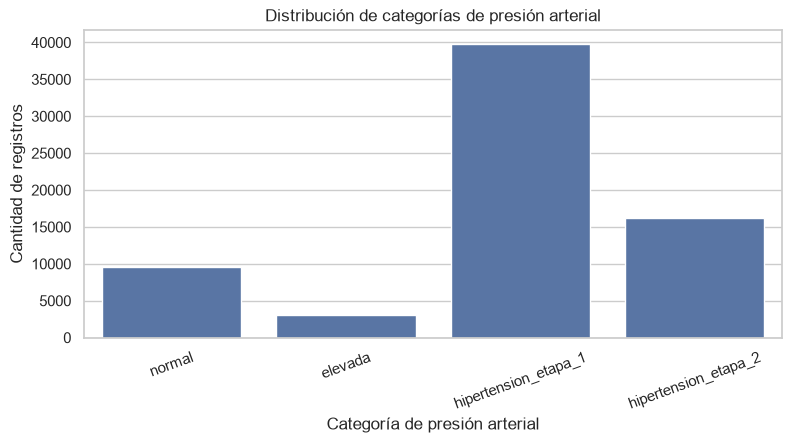

In [23]:
plt.figure(figsize=(9, 4))

sns.countplot(
    data=df,
    x="bp_category",
    order=bp_order
)

plt.title("Distribución de categorías de presión arterial")
plt.xlabel("Categoría de presión arterial")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=20)

plt.show()

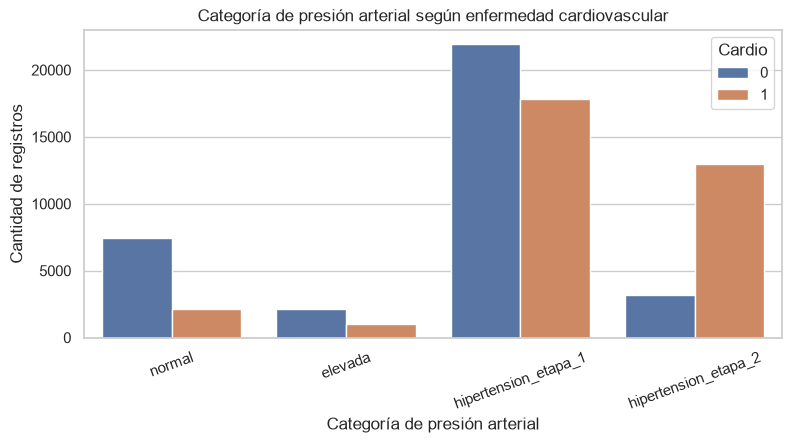

In [24]:
# relación entre presión arterial y enfermedad cardiovascular
plt.figure(figsize=(9, 4))

sns.countplot(
    data=df,
    x="bp_category",
    hue="cardio",
    order=bp_order
)

plt.title("Categoría de presión arterial según enfermedad cardiovascular")
plt.xlabel("Categoría de presión arterial")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=20)
plt.legend(title="Cardio")

plt.show()

In [25]:
bp_cardio_pct = (
    df.groupby("bp_category")["cardio"]
    .mean()
    .reset_index()
)

bp_cardio_pct["Porcentaje_cardio_1"] = bp_cardio_pct["cardio"] * 100

bp_cardio_pct = bp_cardio_pct.set_index("bp_category").reindex(bp_order).reset_index()

bp_cardio_pct

,bp_category,cardio,Porcentaje_cardio_1
0,normal,0.22,22.14
1,elevada,0.32,32.29
2,hipertension_etapa_1,0.45,44.86
3,hipertension_etapa_2,0.80,80.15


In [26]:
bp_cardio_pct = (
    df.groupby("bp_category")["cardio"]
    .mean()
    .reset_index()
)

bp_cardio_pct["Porcentaje_cardio_1"] = bp_cardio_pct["cardio"] * 100

bp_cardio_pct = bp_cardio_pct.set_index("bp_category").reindex(bp_order).reset_index()

bp_cardio_pct

,bp_category,cardio,Porcentaje_cardio_1
0,normal,0.22,22.14
1,elevada,0.32,32.29
2,hipertension_etapa_1,0.45,44.86
3,hipertension_etapa_2,0.80,80.15


## Creacion de indicador de hipertensión

In [27]:
# Crear variable binaria de hipertensión
df["hypertension"] = df["bp_category"].isin(
    ["hipertension_etapa_1", "hipertension_etapa_2"]
).astype(int)

# Revisar distribución
df["hypertension"].value_counts().sort_index()

hypertension
0    12662
1    55974
Name: count, dtype: int64

In [28]:
# Distribución porcentual
df["hypertension"].value_counts(normalize=True).sort_index() * 100

hypertension
0   18.45
1   81.55
Name: proportion, dtype: float64

In [29]:
# relación entre presión arterial y enfermedad cardiovascular

hypertension_cardio_pct = (
    df.groupby("hypertension")["cardio"]
    .mean()
    .reset_index()
)

hypertension_cardio_pct["Porcentaje_cardio_1"] = hypertension_cardio_pct["cardio"] * 100

hypertension_cardio_pct

,hypertension,cardio,Porcentaje_cardio_1
0,0,0.25,24.63
1,1,0.55,55.09


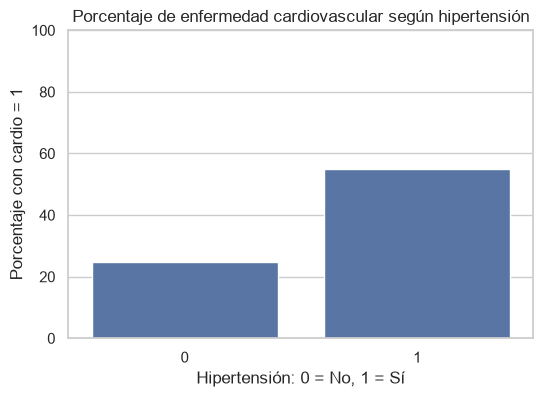

In [30]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=hypertension_cardio_pct,
    x="hypertension",
    y="Porcentaje_cardio_1"
)

plt.title("Porcentaje de enfermedad cardiovascular según hipertensión")
plt.xlabel("Hipertensión: 0 = No, 1 = Sí")
plt.ylabel("Porcentaje con cardio = 1")
plt.ylim(0, 100)

plt.show()

## Creación del riesgo metabólico

In [31]:
# Crear indicador de riesgo metabólico
df["metabolic_risk"] = (
    (df["cholesterol"] > 1) |
    (df["gluc"] > 1) |
    (df["obesity"] == 1)
).astype(int)

# Revisar distribución
df["metabolic_risk"].value_counts().sort_index()

metabolic_risk
0    37612
1    31024
Name: count, dtype: int64

In [32]:
# Distribución porcentual
df["metabolic_risk"].value_counts(normalize=True).sort_index() * 100

metabolic_risk
0   54.80
1   45.20
Name: proportion, dtype: float64

In [33]:
metabolic_cardio_pct = (
    df.groupby("metabolic_risk")["cardio"]
    .mean()
    .reset_index()
)

metabolic_cardio_pct["Porcentaje_cardio_1"] = metabolic_cardio_pct["cardio"] * 100

metabolic_cardio_pct

,metabolic_risk,cardio,Porcentaje_cardio_1
0,0,0.40,39.58
1,1,0.61,61.46


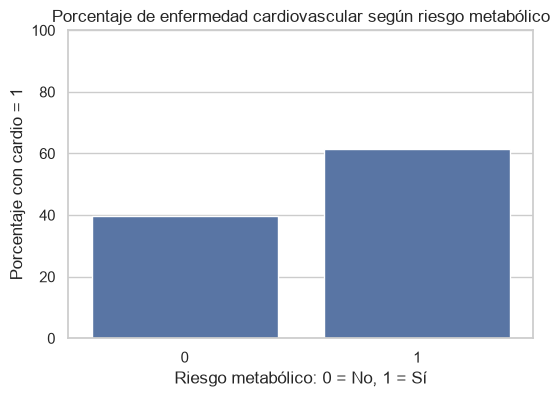

In [34]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=metabolic_cardio_pct,
    x="metabolic_risk",
    y="Porcentaje_cardio_1"
)

plt.title("Porcentaje de enfermedad cardiovascular según riesgo metabólico")
plt.xlabel("Riesgo metabólico: 0 = No, 1 = Sí")
plt.ylabel("Porcentaje con cardio = 1")
plt.ylim(0, 100)

plt.show()

## Creacion de indicador de riesgo por estilo de vida

In [35]:
# Crear indicador de riesgo por estilo de vida
df["lifestyle_risk"] = (
    (df["smoke"] == 1) |
    (df["alco"] == 1) |
    (df["active"] == 0)
).astype(int)

# Revisar distribución
df["lifestyle_risk"].value_counts().sort_index()

lifestyle_risk
0    48537
1    20099
Name: count, dtype: int64

In [37]:
# Distribución porcentual
df["lifestyle_risk"].value_counts(normalize=True).sort_index() * 100

lifestyle_risk
0   70.72
1   29.28
Name: proportion, dtype: float64

In [38]:
lifestyle_cardio_pct = (
    df.groupby("lifestyle_risk")["cardio"]
    .mean()
    .reset_index()
)

lifestyle_cardio_pct["Porcentaje_cardio_1"] = lifestyle_cardio_pct["cardio"] * 100

lifestyle_cardio_pct

,lifestyle_risk,cardio,Porcentaje_cardio_1
0,0,0.49,48.79
1,1,0.51,51.10


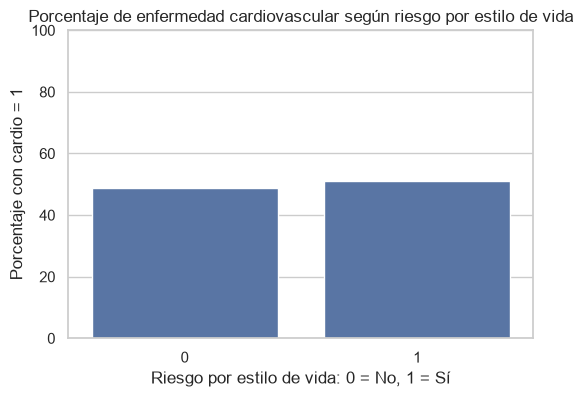

In [39]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=lifestyle_cardio_pct,
    x="lifestyle_risk",
    y="Porcentaje_cardio_1"
)

plt.title("Porcentaje de enfermedad cardiovascular según riesgo por estilo de vida")
plt.xlabel("Riesgo por estilo de vida: 0 = No, 1 = Sí")
plt.ylabel("Porcentaje con cardio = 1")
plt.ylim(0, 100)

plt.show()

## Creación de indicador de riesgo cardio vascular

In [40]:
# Crear puntaje general de riesgo cardiovascular
df["risk_score"] = (
    df["hypertension"] +
    df["obesity"] +
    (df["cholesterol"] > 1).astype(int) +
    (df["gluc"] > 1).astype(int) +
    (df["smoke"] == 1).astype(int) +
    (df["active"] == 0).astype(int)
)

# Revisar distribución del puntaje
df["risk_score"].value_counts().sort_index()

risk_score
0     6314
1    25418
2    21088
3    10789
4     4248
5      728
6       51
Name: count, dtype: int64

In [41]:
# Porcentaje de enfermedad cardiovascular según puntaje de riesgo
risk_score_cardio_pct = (
    df.groupby("risk_score")["cardio"]
    .mean()
    .reset_index()
)

risk_score_cardio_pct["Porcentaje_cardio_1"] = risk_score_cardio_pct["cardio"] * 100

risk_score_cardio_pct

,risk_score,cardio,Porcentaje_cardio_1
0,0,0.20,19.99
1,1,0.41,41.43
2,2,0.54,54.23
3,3,0.66,66.04
4,4,0.71,70.83
5,5,0.76,76.10
6,6,0.75,74.51


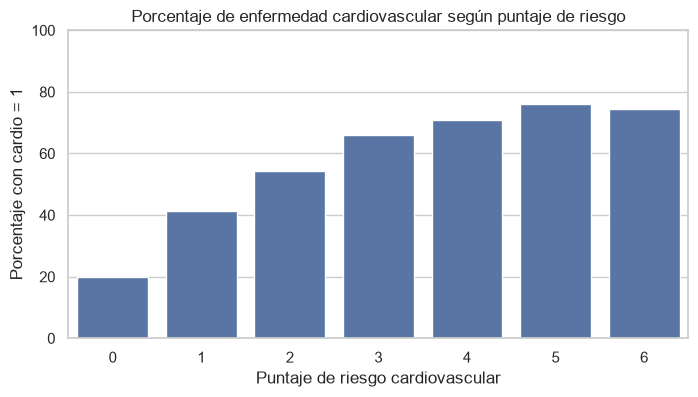

In [42]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=risk_score_cardio_pct,
    x="risk_score",
    y="Porcentaje_cardio_1"
)

plt.title("Porcentaje de enfermedad cardiovascular según puntaje de riesgo")
plt.xlabel("Puntaje de riesgo cardiovascular")
plt.ylabel("Porcentaje con cardio = 1")
plt.ylim(0, 100)

plt.show()

## Revision final

In [43]:
# Variables creadas durante Feature Engineering
variables_creadas = [
    "bmi",
    "bmi_category",
    "obesity",
    "bp_category",
    "hypertension",
    "metabolic_risk",
    "lifestyle_risk",
    "risk_score"
]

# Visualizar primeras filas de las variables creadas
df[variables_creadas].head()

,bmi,bmi_category,obesity,bp_category,hypertension,metabolic_risk,lifestyle_risk,risk_score
0,21.97,normal,0,hipertension_etapa_1,1,0,0,1
1,34.93,obesidad,1,hipertension_etapa_2,1,1,0,3
2,23.51,normal,0,hipertension_etapa_1,1,1,1,3
3,28.71,sobrepeso,0,hipertension_etapa_2,1,0,0,1
4,23.01,normal,0,normal,0,0,1,1


In [44]:
# Revisar columnas finales del dataset
df.columns.tolist()

['age_years',
 'gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'cardio',
 'bmi',
 'bmi_category',
 'obesity',
 'bp_category',
 'hypertension',
 'metabolic_risk',
 'lifestyle_risk',
 'risk_score']

In [45]:
# Seleccionar variables numéricas para correlación
numeric_cols_fe = df.select_dtypes(include=["int64", "float64"]).columns

numeric_cols_fe

Index(['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi',
       'obesity', 'hypertension', 'metabolic_risk', 'lifestyle_risk',
       'risk_score'],
      dtype='str')

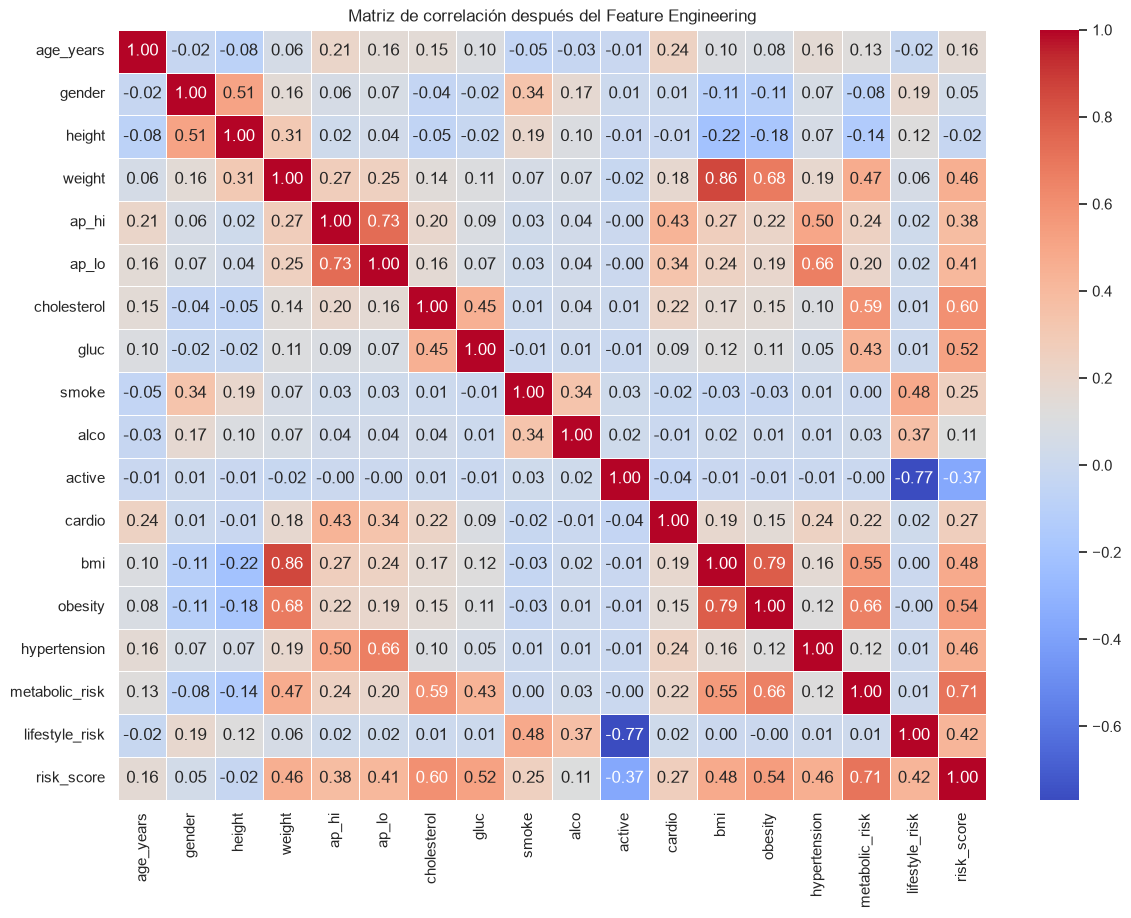

In [46]:
# Matriz de correlación con variables numéricas
correlation_matrix_fe = df[numeric_cols_fe].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix_fe,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de correlación después del Feature Engineering")
plt.show()

In [47]:
# Correlación de variables numéricas con cardio
correlation_with_cardio_fe = (
    correlation_matrix_fe["cardio"]
    .drop("cardio")
    .sort_values(ascending=False)
)

correlation_with_cardio_fe

ap_hi             0.43
ap_lo             0.34
risk_score        0.27
age_years         0.24
hypertension      0.24
cholesterol       0.22
metabolic_risk    0.22
bmi               0.19
weight            0.18
obesity           0.15
gluc              0.09
lifestyle_risk    0.02
gender            0.01
alco             -0.01
height           -0.01
smoke            -0.02
active           -0.04
Name: cardio, dtype: float64

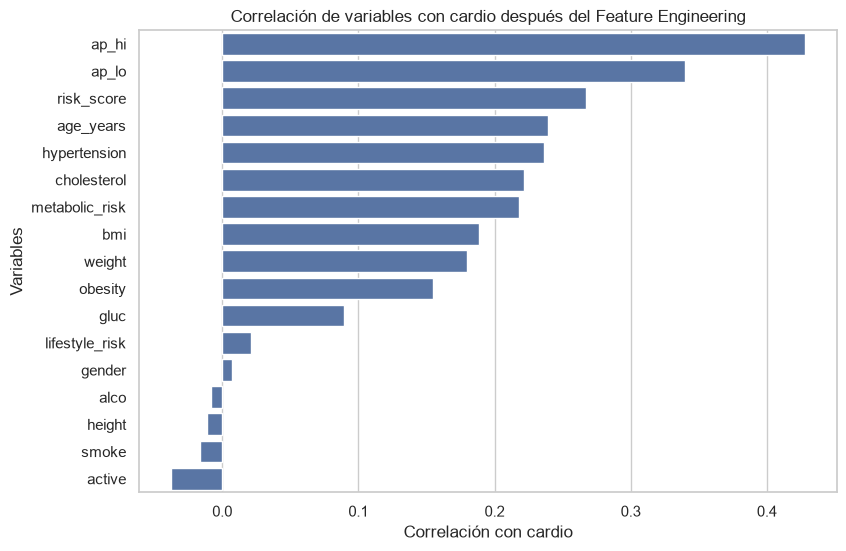

In [48]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=correlation_with_cardio_fe.values,
    y=correlation_with_cardio_fe.index
)

plt.title("Correlación de variables con cardio después del Feature Engineering")
plt.xlabel("Correlación con cardio")
plt.ylabel("Variables")

plt.show()

## Prueba chi-cuadrado para variables categoricas

In [ ]:

# H0: No hay asociación entre la categoría de presión arterial y la presencia de enfermedad cardiovascular (cardio).
# H1: Existe una asociación entre la categoría de presión arterial y la presencia de enfermedad cardiovascular (cardio).
from scipy.stats import chi2_contingency

# Tabla de contingencia entre categoría de presión arterial y cardio
tabla_bp_cardio = pd.crosstab(df["bp_category"], df["cardio"])

tabla_bp_cardio

cardio,0,1
bp_category,,
elevada,2107,1005
hipertension_etapa_1,21920,17830
hipertension_etapa_2,3220,13004
normal,7436,2114


In [54]:
# Prueba Chi-cuadrado
chi2, p_value, dof, expected = chi2_contingency(tabla_bp_cardio)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Grados de libertad: {dof}")

Chi-cuadrado: 9670.5376
p-value: 0.000000
Grados de libertad: 3


Existe correlacion entre las variables

## Guardar datasets

In [49]:
# Guardar dataset completo con todas las variables originales limpias y derivadas
df.to_csv("cardio_features_full.csv", index=False)

print("Dataset completo guardado como cardio_features_full.csv")
print("Dimensiones:", df.shape)

Dataset completo guardado como cardio_features_full.csv
Dimensiones: (68636, 20)


In [50]:
# Variables seleccionadas para una versión reducida del dataset
features_reducidas = [
    "age_years",
    "gender",
    "height",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "bmi",
    "bp_category",
    "hypertension",
    "metabolic_risk",
    "risk_score",
    "cardio"
]

# Crear dataset reducido
df_reduced = df[features_reducidas].copy()

# Guardar dataset reducido
df_reduced.to_csv("cardio_features_reduced.csv", index=False)

print("Dataset reducido guardado como cardio_features_reduced.csv")
print("Dimensiones:", df_reduced.shape)

Dataset reducido guardado como cardio_features_reduced.csv
Dimensiones: (68636, 16)


In [51]:
# Seleccionar solo variables numéricas del dataset reducido
numeric_cols_reduced = df_reduced.select_dtypes(include=["int64", "float64"]).columns

numeric_cols_reduced

Index(['age_years', 'gender', 'height', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'bmi', 'hypertension',
       'metabolic_risk', 'risk_score', 'cardio'],
      dtype='str')

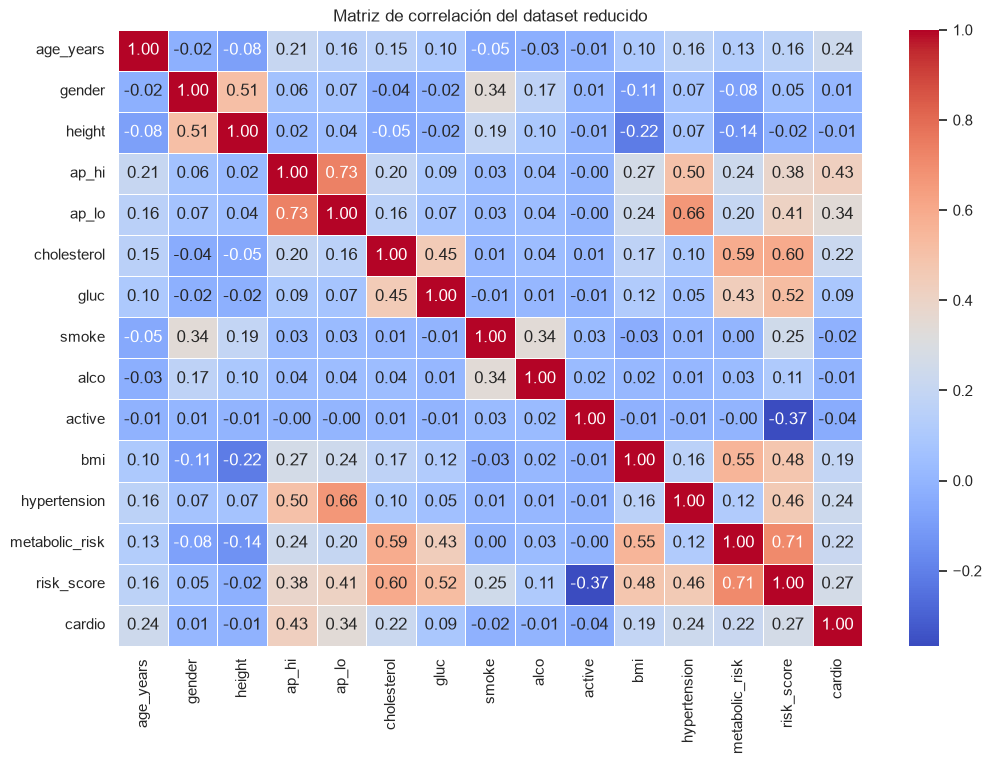

In [52]:
# Matriz de correlación del dataset reducido
correlation_matrix_reduced = df_reduced[numeric_cols_reduced].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix_reduced,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de correlación del dataset reducido")
plt.show()

# Resumen de variables creadas en Feature Engineering

| Variable creada  | ¿Qué indica?                                         | Variables utilizadas                                                | Criterio / fórmula utilizada                                                                                                                                                                            | Tipo de variable            | ¿Qué indica cada valor?                                                                                                                         |
| ---------------- | ---------------------------------------------------- | ------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------- |
| `bmi`            | Índice de Masa Corporal de la persona                | `weight`, `height`                                                  | `bmi = weight / (height / 100)^2`                                                                                                                                                                       | Numérica continua           | Valor numérico del IMC. A mayor valor, mayor relación peso-altura.                                                                              |
| `bmi_category`   | Clasificación del IMC en categorías                  | `bmi`                                                               | Bajo peso: `< 18.5`; Normal: `18.5 - 24.9`; Sobrepeso: `25 - 29.9`; Obesidad: `>= 30`                                                                                                                   | Categórica ordinal          | `bajo_peso`: IMC bajo; `normal`: IMC saludable; `sobrepeso`: IMC elevado; `obesidad`: IMC igual o mayor a 30.                                   |
| `obesity`        | Indica si la persona presenta obesidad               | `bmi`                                                               | `obesity = 1` si `bmi >= 30`, caso contrario `0`                                                                                                                                                        | Binaria                     | `0`: no presenta obesidad; `1`: presenta obesidad.                                                                                              |
| `bp_category`    | Clasificación de la presión arterial                 | `ap_hi`, `ap_lo`                                                    | Normal: `ap_hi < 120` y `ap_lo < 80`; Elevada: `120 <= ap_hi < 130` y `ap_lo < 80`; Hipertensión etapa 1: `130 <= ap_hi < 140` o `80 <= ap_lo < 90`; Hipertensión etapa 2: valores superiores a etapa 1 | Categórica ordinal          | `normal`: presión normal; `elevada`: presión elevada; `hipertension_etapa_1`: hipertensión moderada; `hipertension_etapa_2`: hipertensión alta. |
| `hypertension`   | Indica si la persona presenta hipertensión           | `bp_category`                                                       | `hypertension = 1` si `bp_category` es `hipertension_etapa_1` o `hipertension_etapa_2`                                                                                                                  | Binaria                     | `0`: no presenta hipertensión; `1`: presenta hipertensión.                                                                                      |
| `metabolic_risk` | Indica presencia de riesgo metabólico                | `cholesterol`, `gluc`, `obesity`                                    | `metabolic_risk = 1` si `cholesterol > 1` o `gluc > 1` o `obesity = 1`                                                                                                                                  | Binaria                     | `0`: no presenta riesgo metabólico según las variables usadas; `1`: presenta al menos un factor metabólico de riesgo.                           |
| `lifestyle_risk` | Indica presencia de riesgo por hábitos de vida       | `smoke`, `alco`, `active`                                           | `lifestyle_risk = 1` si `smoke = 1` o `alco = 1` o `active = 0`                                                                                                                                         | Binaria                     | `0`: no fuma, no consume alcohol y realiza actividad física; `1`: presenta al menos un hábito de riesgo.                                        |
| `risk_score`     | Puntaje general de acumulación de factores de riesgo | `hypertension`, `obesity`, `cholesterol`, `gluc`, `smoke`, `active` | Suma de factores: hipertensión + obesidad + colesterol elevado + glucosa elevada + tabaquismo + falta de actividad física                                                                               | Numérica discreta / ordinal | Valor de `0` a `6`. Mientras mayor sea el puntaje, mayor cantidad de factores de riesgo acumula la persona.                                     |


## Ajuste 1

In [57]:

# NUEVAS VARIABLES FISIOLOGICAS


df_fase1 = df.copy()

df_fase1["pulse_pressure"] = df_fase1["ap_hi"] - df_fase1["ap_lo"]

df_fase1["mean_arterial_pressure"] = (
    (2 * df_fase1["ap_lo"] + df_fase1["ap_hi"]) / 3
)

df_fase1["age_pressure"] = df_fase1["age_years"] * df_fase1["ap_hi"]

nuevas_vars = [
    "pulse_pressure",
    "mean_arterial_pressure",
    "age_pressure"
]

df_fase1[nuevas_vars].head()

,pulse_pressure,mean_arterial_pressure,age_pressure
0,30,90.00,5500
1,50,106.67,7700
2,60,90.00,6630
3,50,116.67,7200
4,40,73.33,4700


In [58]:
df_fase1[nuevas_vars].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
pulse_pressure,68636.00,45.37,11.68,5.00,20.00,30.00,40.00,40.00,50.00,70.00,80.00,140.00
mean_arterial_pressure,68636.00,96.42,11.04,46.67,70.00,80.00,93.33,93.33,103.33,116.67,126.67,180.00
age_pressure,68636.00,6715.46,1355.39,2580.00,4100.00,4680.00,5760.00,6630.00,7560.00,9120.00,10240.00,14640.00


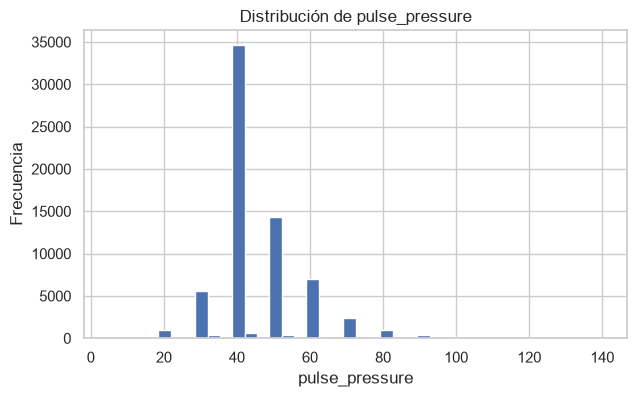

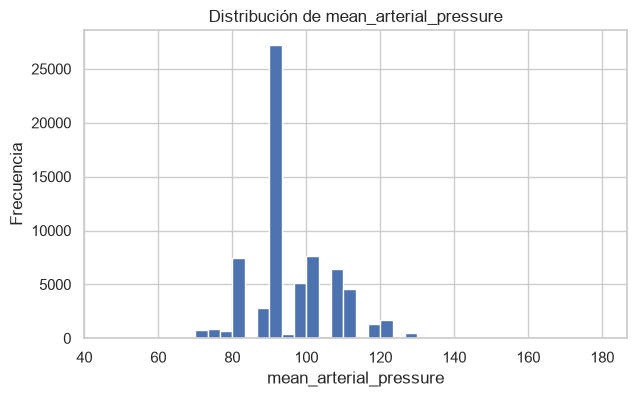

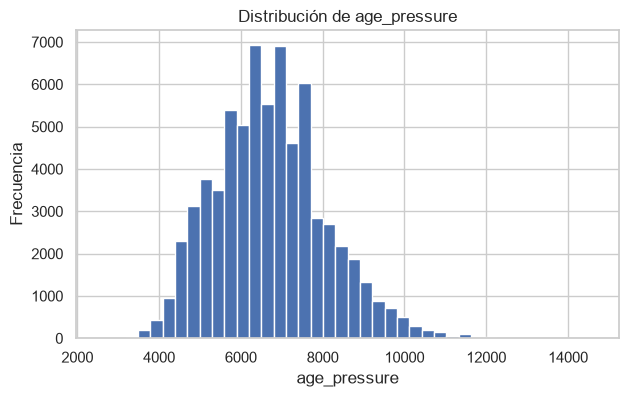

In [59]:
import matplotlib.pyplot as plt

for var in nuevas_vars:
    plt.figure(figsize=(7, 4))
    plt.hist(df_fase1[var], bins=40)
    plt.title(f"Distribución de {var}")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")
    plt.show()

C:\Users\igorc\AppData\Local\Temp\ipykernel_30780\1565636216.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_fase1[var], vert=False)


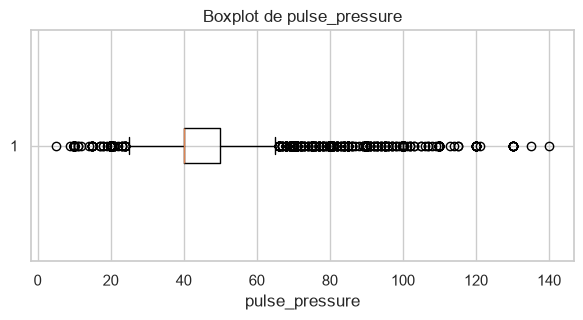

C:\Users\igorc\AppData\Local\Temp\ipykernel_30780\1565636216.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_fase1[var], vert=False)


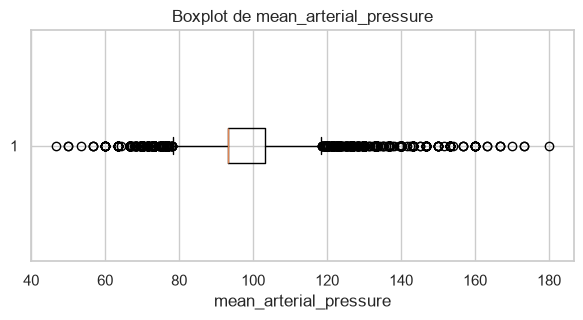

C:\Users\igorc\AppData\Local\Temp\ipykernel_30780\1565636216.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_fase1[var], vert=False)


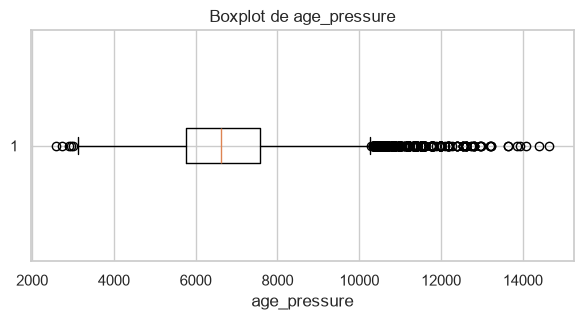

In [60]:
for var in nuevas_vars:
    plt.figure(figsize=(7, 3))
    plt.boxplot(df_fase1[var], vert=False)
    plt.title(f"Boxplot de {var}")
    plt.xlabel(var)
    plt.show()

In [61]:
corr_fase1 = df_fase1[
    [
        "ap_hi",
        "ap_lo",
        "age_years",
        "pulse_pressure",
        "mean_arterial_pressure",
        "age_pressure",
        "cardio"
    ]
].corr(numeric_only=True)

corr_fase1["cardio"].sort_values(ascending=False)

cardio                   1.00
ap_hi                    0.43
age_pressure             0.42
mean_arterial_pressure   0.41
ap_lo                    0.34
pulse_pressure           0.34
age_years                0.24
Name: cardio, dtype: float64

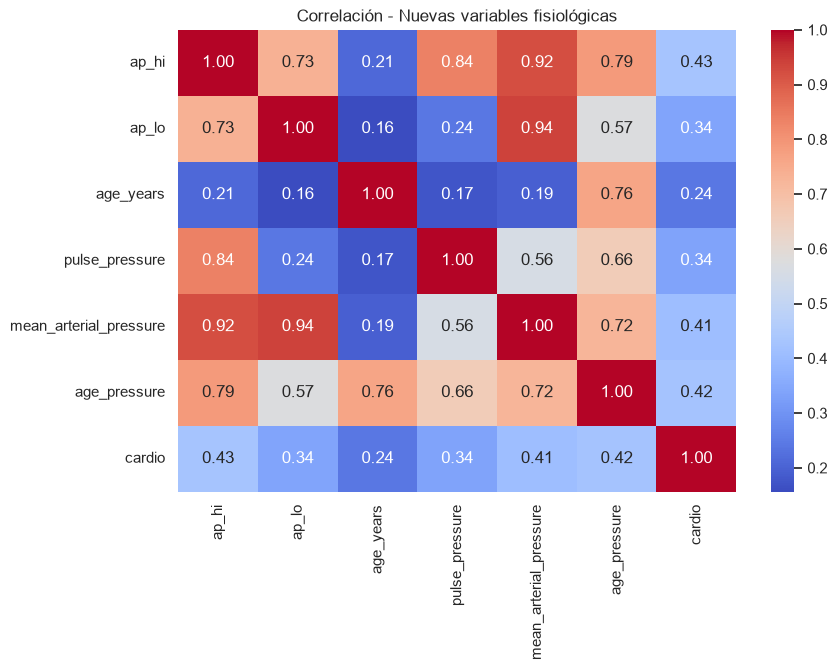

: 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
sns.heatmap(
    corr_fase1,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlación - Nuevas variables fisiológicas")
plt.show()